# Семестровая работа. Выполнил Цвиль Павел, ФИТ-231.
## Вариант 3


Изучите сортировку выбором и реализуйте ее в виде функции selection_sort(some_list). Функция принимает список и сортирует его по возрастанию.

In [5]:
import time
import random
import matplotlib.pyplot as plt
import sys

# Увеличиваем лимит рекурсии (на всякий случай)
sys.setrecursionlimit(10000)

def selection_sort(arr):
    """
    Сортировка выбором.
    На каждом шаге ищет минимальный элемент и ставит его на своё место.
    Возвращает кортеж (отсортированный список, количество сравнений, количество перестановок)
    """
    comparisons = 0  # счётчик сравнений
    swaps = 0        # счётчик перестановок
    lst = arr.copy() # работаем с копией, чтобы не испортить исходный
    
    n = len(lst)
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            comparisons += 1
            if lst[j] < lst[min_idx]:
                min_idx = j
        
        if min_idx != i:
            lst[i], lst[min_idx] = lst[min_idx], lst[i]
            swaps += 1
    
    return lst, comparisons, swaps

def selection_sort_with_steps(arr):
    """
    Версия для пошагового вывода.
    """
    lst = arr.copy()
    n = len(lst)
    steps = []
    
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if lst[j] < lst[min_idx]:
                min_idx = j
        
        if min_idx != i:
            lst[i], lst[min_idx] = lst[min_idx], lst[i]
        
        steps.append(lst.copy())
    
    return steps

## Задание 1
Выпишите состояние списка [7, 3, 9, 4, 2, 5, 6, 1, 8] после каждой итерации алгоритма сортировки выбором. Сколько сравнений и перестановок было выполнено?

In [3]:
arr1 = [7, 3, 9, 4, 2, 5, 6, 1, 8]
print(f"Исходный список: {arr1}\n")

# Получаем пошаговые состояния
steps = selection_sort_with_steps(arr1)

print("Состояние списка после каждой итерации:")
for i, step in enumerate(steps, 1):
    # Выделяем уже отсортированную часть (первые i элементов)
    sorted_part = step[:i]
    unsorted_part = step[i:]
    print(f"  Итерация {i}: {sorted_part} | {unsorted_part}")

# Подсчёт сравнений и перестановок
sorted_arr, comparisons, swaps = selection_sort(arr1)
print(f"\nОбщее количество сравнений: {comparisons}")
print(f"Общее количество перестановок: {swaps}")
print(f"Отсортированный список: {sorted_arr}")


lst = [7, 3, 9, 4, 2, 5, 6, 1, 8]
n = len(lst)
total_comparisons = 0
total_swaps = 0

for i in range(n):
    min_idx = i
    print(f"\nИтерация {i+1}: ищем минимум среди элементов с {i} по {n-1}")
    print(f"  Текущий список: {lst}")
    
    for j in range(i + 1, n):
        total_comparisons += 1
        print(f"    Сравниваем lst[{j}]={lst[j]} с lst[{min_idx}]={lst[min_idx]}", end=" ")
        if lst[j] < lst[min_idx]:
            min_idx = j
            print(f" новый минимум в позиции {j} (значение {lst[j]})")
        else:
            print(f" минимум остаётся в позиции {min_idx}")
    
    if min_idx != i:
        lst[i], lst[min_idx] = lst[min_idx], lst[i]
        total_swaps += 1
        print(f"  Меняем местами lst[{i}]={lst[i]} и lst[{min_idx}]={lst[min_idx]}")
        print(f"  Результат: {lst}")
    else:
        print(f"  Элемент lst[{i}]={lst[i]} уже на своём месте, перестановка не нужна")

Исходный список: [7, 3, 9, 4, 2, 5, 6, 1, 8]

Состояние списка после каждой итерации:
  Итерация 1: [1] | [3, 9, 4, 2, 5, 6, 7, 8]
  Итерация 2: [1, 2] | [9, 4, 3, 5, 6, 7, 8]
  Итерация 3: [1, 2, 3] | [4, 9, 5, 6, 7, 8]
  Итерация 4: [1, 2, 3, 4] | [9, 5, 6, 7, 8]
  Итерация 5: [1, 2, 3, 4, 5] | [9, 6, 7, 8]
  Итерация 6: [1, 2, 3, 4, 5, 6] | [9, 7, 8]
  Итерация 7: [1, 2, 3, 4, 5, 6, 7] | [9, 8]
  Итерация 8: [1, 2, 3, 4, 5, 6, 7, 8] | [9]
  Итерация 9: [1, 2, 3, 4, 5, 6, 7, 8, 9] | []

Общее количество сравнений: 36
Общее количество перестановок: 7
Отсортированный список: [1, 2, 3, 4, 5, 6, 7, 8, 9]

Итерация 1: ищем минимум среди элементов с 0 по 8
  Текущий список: [7, 3, 9, 4, 2, 5, 6, 1, 8]
    Сравниваем lst[1]=3 с lst[0]=7  новый минимум в позиции 1 (значение 3)
    Сравниваем lst[2]=9 с lst[1]=3  минимум остаётся в позиции 1
    Сравниваем lst[3]=4 с lst[1]=3  минимум остаётся в позиции 1
    Сравниваем lst[4]=2 с lst[1]=3  новый минимум в позиции 4 (значение 2)
    Сравнивае

## Задание 2

Выпишите состояние списка [3, 5, 2, 9, 8, 1, 6, 4, 7] после каждой итерации алгоритма сортировки выбором. Сколько сравнений и перестановок было выполнено?


In [9]:
arr = [3, 5, 2, 9, 8, 1, 6, 4, 7]
print(f"Исходный список: {arr}\n")

lst = arr.copy()
n = len(lst)
comparisons = 0
swaps = 0

for i in range(n):
    min_idx = i
    print(f"Итерация {i+1}: ищем минимум среди элементов с {i} по {n-1}")
    for j in range(i + 1, n):
        comparisons += 1
        print(f"  Сравниваем {lst[j]} и {lst[min_idx]}", end=" -> ")
        if lst[j] < lst[min_idx]:
            min_idx = j
            print(f"новый минимум {lst[j]} на позиции {j}")
        else:
            print("минимум не изменился")
    
    if min_idx != i:
        lst[i], lst[min_idx] = lst[min_idx], lst[i]
        swaps += 1
        print(f"  Меняем местами {lst[i]} и {lst[min_idx]}")
    
    print(f"  Результат итерации {i+1}: {lst}\n")

print("=" * 60)
print("ИТОГИ:")
print(f"  Всего сравнений: {comparisons}")
print(f"  Всего перестановок: {swaps}")
print(f"  Отсортированный список: {lst}")

Исходный список: [3, 5, 2, 9, 8, 1, 6, 4, 7]

Итерация 1: ищем минимум среди элементов с 0 по 8
  Сравниваем 5 и 3 -> минимум не изменился
  Сравниваем 2 и 3 -> новый минимум 2 на позиции 2
  Сравниваем 9 и 2 -> минимум не изменился
  Сравниваем 8 и 2 -> минимум не изменился
  Сравниваем 1 и 2 -> новый минимум 1 на позиции 5
  Сравниваем 6 и 1 -> минимум не изменился
  Сравниваем 4 и 1 -> минимум не изменился
  Сравниваем 7 и 1 -> минимум не изменился
  Меняем местами 1 и 3
  Результат итерации 1: [1, 5, 2, 9, 8, 3, 6, 4, 7]

Итерация 2: ищем минимум среди элементов с 1 по 8
  Сравниваем 2 и 5 -> новый минимум 2 на позиции 2
  Сравниваем 9 и 2 -> минимум не изменился
  Сравниваем 8 и 2 -> минимум не изменился
  Сравниваем 3 и 2 -> минимум не изменился
  Сравниваем 6 и 2 -> минимум не изменился
  Сравниваем 4 и 2 -> минимум не изменился
  Сравниваем 7 и 2 -> минимум не изменился
  Меняем местами 2 и 5
  Результат итерации 2: [1, 2, 5, 9, 8, 3, 6, 4, 7]

Итерация 3: ищем минимум среди эл

## Задание 3

Проведите анализ асимптотической сложности алгоритма сортировки. Напишите значения его временной и пространственной сложностей.

ЗАДАНИЕ 3: Анализ асимптотической сложности сортировки выбором


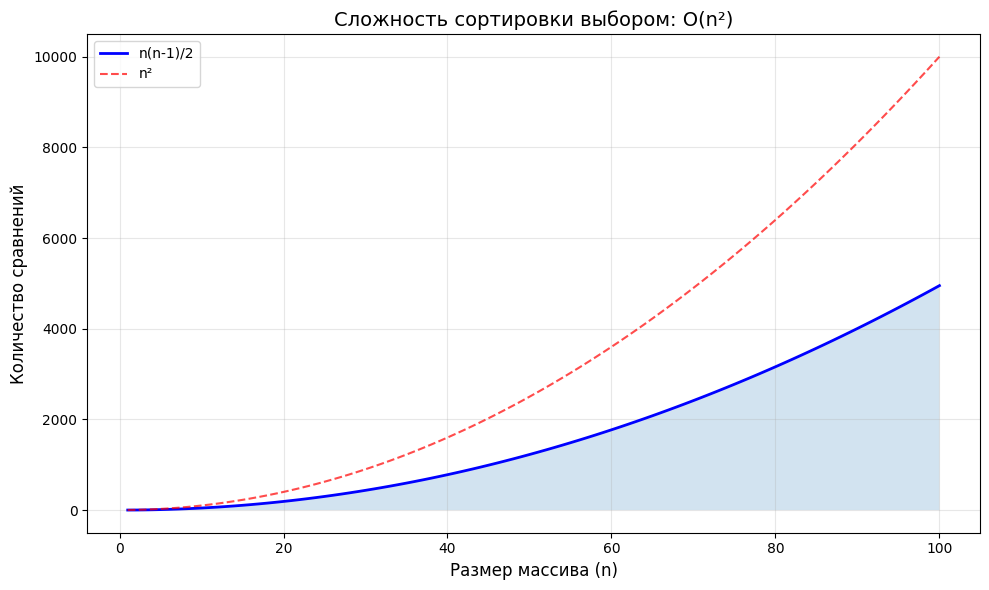


Вывод: график наглядно демонстрирует квадратичный рост количества
сравнений при увеличении размера массива. Для n = 40 выполняется
около 1800 сравнений, а для n = 100 — уже около 5000 сравнений.



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("ЗАДАНИЕ 3: Анализ асимптотической сложности сортировки выбором")


# Построение графика сложности O(n²)
n_values = np.arange(1, 101, 1)
comparisons = [n*(n-1)/2 for n in n_values]

plt.figure(figsize=(10, 6))
plt.plot(n_values, comparisons, 'b-', linewidth=2, label='n(n-1)/2')
plt.plot(n_values, n_values**2, 'r--', linewidth=1.5, alpha=0.7, label='n²')
plt.fill_between(n_values, comparisons, alpha=0.2)
plt.xlabel('Размер массива (n)', fontsize=12)
plt.ylabel('Количество сравнений', fontsize=12)
plt.title('Сложность сортировки выбором: O(n²)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('selection_sort_complexity.png', dpi=150)
plt.show()

print("""
Вывод: график наглядно демонстрирует квадратичный рост количества
сравнений при увеличении размера массива. Для n = 40 выполняется
около 1800 сравнений, а для n = 100 — уже около 5000 сравнений.
""")

## Задание 4

Проведите вычислительные эксперименты и нарисуйте графики, показывающие зависимость времени выполнения от размера входных данных n. Возьмите n равное: 100, 500, 1000, 2000, 4000, 6000, 8000, 10000. 
Реализуйте функции для генерации следующих вариантов входных данных: 
a.	список случайных чисел; 
b.	отсортированный в обратную сторону список;
c.	почти отсортированный список (один элемент в середине списка находится не на своем месте); 
d.	половина данных равна 0, а половина – случайные целочисленные значения; 
e.	все элементы находятся в пределах 10 позиций от окончательного места в массиве.
График зависимостей должен быть представлен для каждого варианта входных данных. 
На каком из вариантов сортировка работает быстрее всего? На каком из вариантов – медленнее? Как вы можете это объяснить?  



Размеры массивов: [100, 500, 1000, 2000, 4000, 6000, 8000, 10000]
Типы данных: a, b, c, d, e

Тестирование: a. Случайные числа
  n =   100, время = 0.000176 сек
  n =   500, время = 0.004090 сек
  n =  1000, время = 0.015258 сек
  n =  2000, время = 0.059860 сек
  n =  4000, время = 0.240402 сек
  n =  6000, время = 0.561167 сек
  n =  8000, время = 0.964374 сек
  n = 10000, время = 1.494908 сек

Тестирование: b. Обратный порядок
  n =   100, время = 0.000166 сек
  n =   500, время = 0.004191 сек
  n =  1000, время = 0.017369 сек
  n =  2000, время = 0.067696 сек
  n =  4000, время = 0.267327 сек
  n =  6000, время = 0.600940 сек
  n =  8000, время = 1.061153 сек
  n = 10000, время = 1.663650 сек

Тестирование: c. Почти отсортированный
  n =   100, время = 0.000140 сек
  n =   500, время = 0.003671 сек
  n =  1000, время = 0.015019 сек
  n =  2000, время = 0.059939 сек
  n =  4000, время = 0.238835 сек
  n =  6000, время = 0.533324 сек
  n =  8000, время = 0.954316 сек
  n = 10000, вр

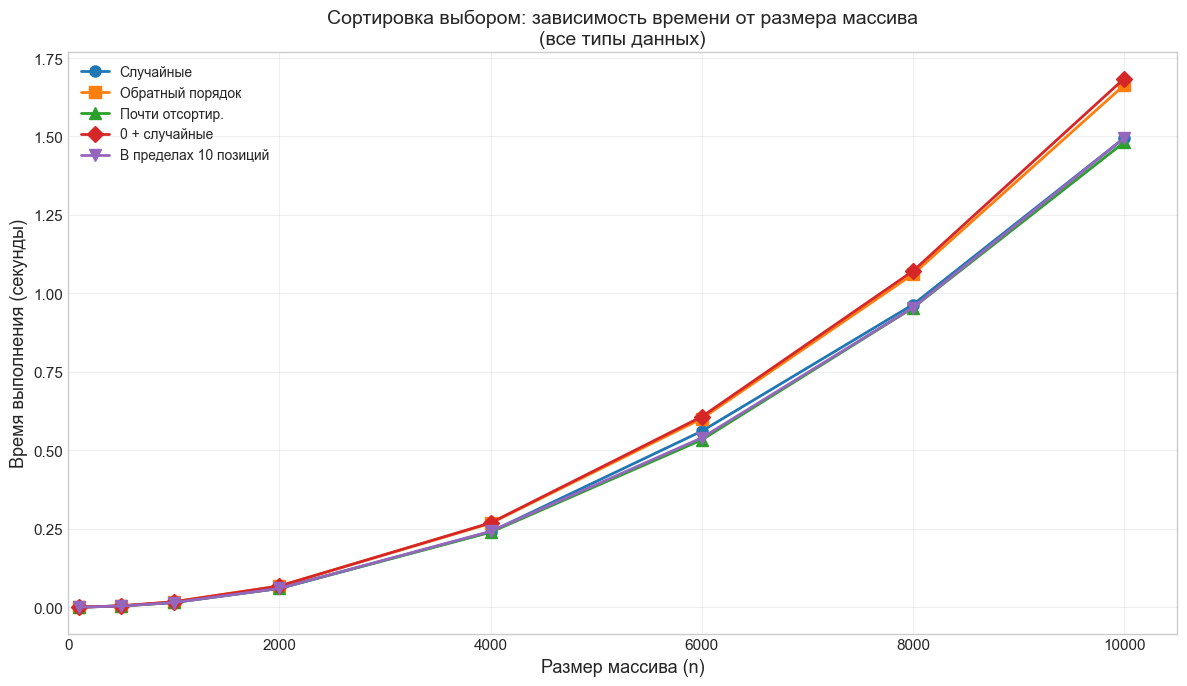

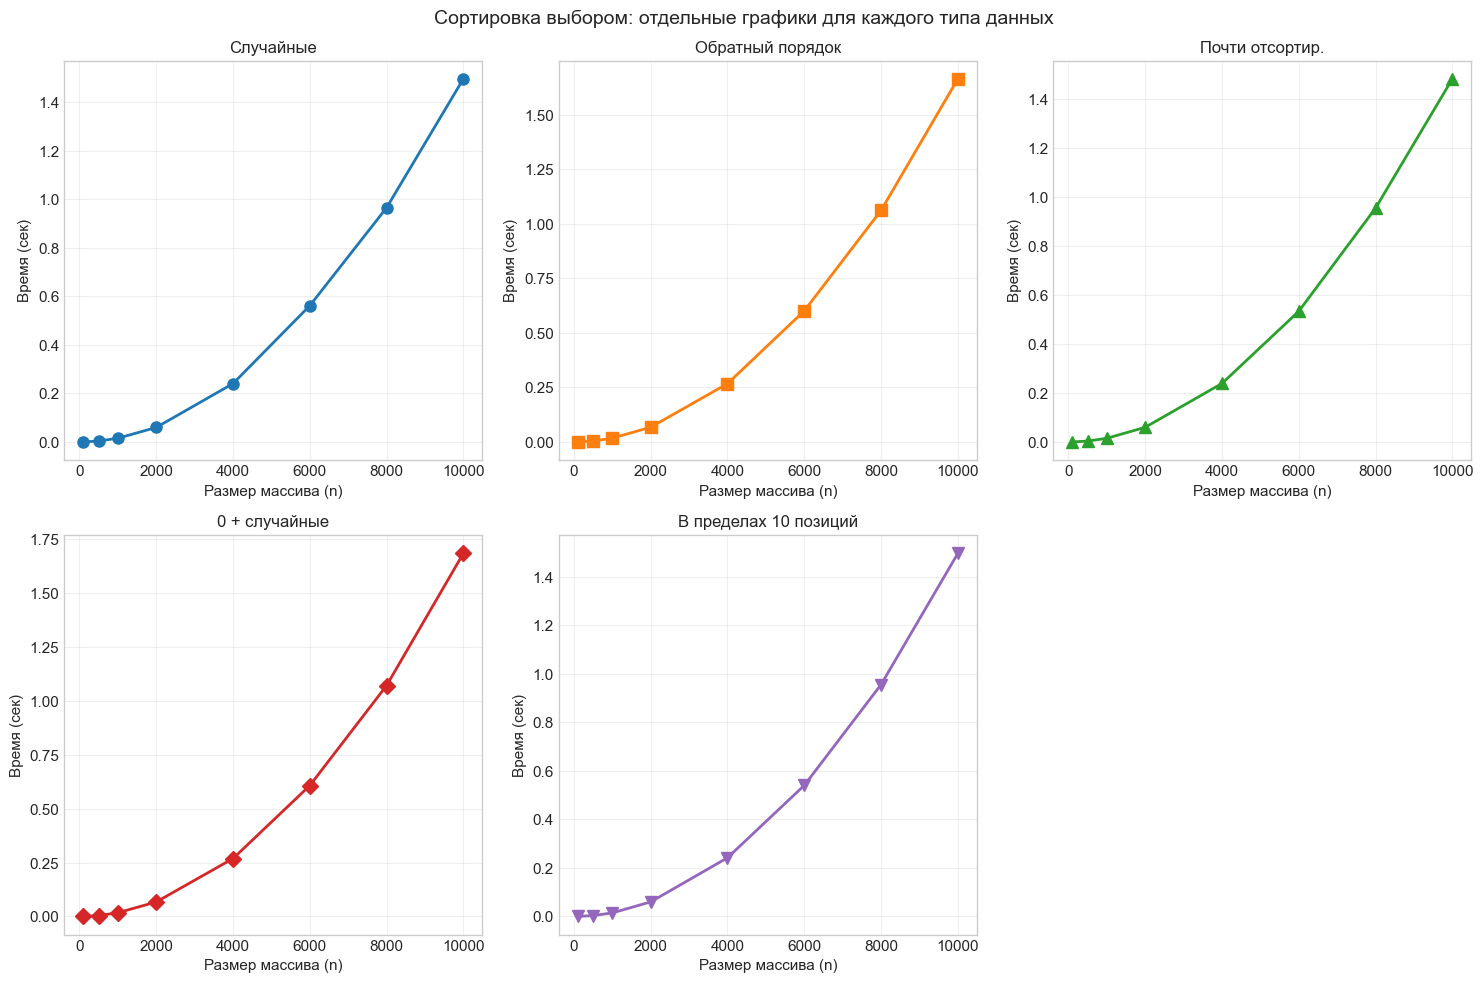

АНАЛИЗ РЕЗУЛЬТАТОВ

Для n = 10000:
  БЫСТРЕЕ всего работает на типе: c. Почти отсортированный (1.481590 сек)
  МЕДЛЕННЕЕ всего работает на типе: d. Половина нулей, половина случайных (1.684599 сек)

------------------------------------------------------------
ОБЪЯСНЕНИЕ РЕЗУЛЬТАТОВ:
------------------------------------------------------------

1. Сортировка выбором всегда выполняет n(n-1)/2 сравнений,
   независимо от исходного порядка элементов.

2. Разница во времени связана в основном с количеством перестановок:
   - На почти отсортированных данных перестановок мало → быстрее
   - На обратном порядке перестановок много → медленнее

3. На случайных данных время находится посередине.

4. На типе 'половина нулей' перестановок может быть меньше,
   так как много одинаковых элементов.

5. На типе 'в пределах 10 позиций' элементы уже почти на своих местах,
   поэтому перестановок мало → время близко к минимальному.

ВЫВОД: Сортировка выбором показывает одинаковую временную сложность O(n²)

In [ ]:
import time
import random
import matplotlib.pyplot as plt
import numpy as np

# ========== ФУНКЦИЯ СОРТИРОВКИ ВЫБОРОМ ==========
def selection_sort(arr):
    lst = arr.copy()
    n = len(lst)
    for i in range(n):
        min_idx = i
        for j in range(i + 1, n):
            if lst[j] < lst[min_idx]:
                min_idx = j
        if min_idx != i:
            lst[i], lst[min_idx] = lst[min_idx], lst[i]
    return lst

# ========== ГЕНЕРАТОРЫ ВХОДНЫХ ДАННЫХ ==========
def random_list(n, max_val=10000):
    """a. список случайных чисел"""
    return [random.randint(0, max_val) for _ in range(n)]

def reversed_list(n):
    """b. отсортированный в обратную сторону список"""
    return list(range(n, 0, -1))

def almost_sorted_list(n):
    """c. почти отсортированный список (один элемент не на своём месте)"""
    lst = list(range(n))
    if n > 1:
        mid = n // 2
        lst[mid], lst[mid + 1] = lst[mid + 1], lst[mid]
    return lst

def half_zero_half_random(n, max_val=10000):
    """d. половина данных равна 0, а половина - случайные"""
    half = n // 2
    lst = [0] * half + [random.randint(1, max_val) for _ in range(n - half)]
    random.shuffle(lst)
    return lst

def close_to_final_position(n):
    """e. все элементы в пределах 10 позиций от окончательного места"""
    lst = list(range(n))
    for i in range(n):
        shift = random.randint(-10, 10)
        j = max(0, min(n - 1, i + shift))
        lst[i], lst[j] = lst[j], lst[i]
    return lst

# ========== ФУНКЦИЯ ДЛЯ ЗАМЕРА ВРЕМЕНИ ==========
def measure_time(sort_func, arr):
    start = time.perf_counter()
    sort_func(arr)
    end = time.perf_counter()
    return end - start

# ========== ПАРАМЕТРЫ ЭКСПЕРИМЕНТА ==========
sizes = [100, 500, 1000, 2000, 4000, 6000, 8000, 10000]
data_types = {
    'a. Случайные числа': random_list,
    'b. Обратный порядок': reversed_list,
    'c. Почти отсортированный': almost_sorted_list,
    'd. Половина нулей, половина случайных': half_zero_half_random,
    'e. В пределах 10 позиций': close_to_final_position
}

# Словарь для хранения результатов
results = {name: [] for name in data_types}

print(f"\nРазмеры массивов: {sizes}")
print("Типы данных: a, b, c, d, e\n")

# Проведение экспериментов
for name, generator in data_types.items():
    print(f"Тестирование: {name}")
    for n in sizes:
        arr = generator(n)
        duration = measure_time(selection_sort, arr)
        results[name].append(duration)
        print(f"  n = {n:5d}, время = {duration:.6f} сек")
    print()

# ========== ПОСТРОЕНИЕ ГРАФИКОВ ==========
# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11

# Цвета и маркеры для разных типов данных
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', '^', 'D', 'v']
labels = ['Случайные', 'Обратный порядок', 'Почти отсортир.', '0 + случайные', 'В пределах 10 позиций']

# 1. Общий график для всех типов данных
fig, ax = plt.subplots(figsize=(12, 7))

for (name, times), color, marker, label in zip(results.items(), colors, markers, labels):
    ax.plot(sizes, times, label=label, marker=marker, linewidth=2, 
            markersize=8, color=color)

ax.set_xlabel('Размер массива (n)', fontsize=13)
ax.set_ylabel('Время выполнения (секунды)', fontsize=13)
ax.set_title('Сортировка выбором: зависимость времени от размера массива\n(все типы данных)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(sizes) * 1.05)

plt.tight_layout()
plt.savefig('selection_sort_all_types.png', dpi=150)
plt.show()

# 2. Отдельные графики для каждого типа данных
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, ((name, times), color, marker, label) in enumerate(zip(results.items(), colors, markers, labels)):
    ax = axes[idx]
    ax.plot(sizes, times, marker=marker, linewidth=2, markersize=8, color=color)
    ax.set_xlabel('Размер массива (n)', fontsize=11)
    ax.set_ylabel('Время (сек)', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.grid(True, alpha=0.3)

# Убираем лишний подграфик (2x3 = 6, а у нас 5 типов)
axes[5].axis('off')

plt.suptitle('Сортировка выбором: отдельные графики для каждого типа данных', fontsize=14)
plt.tight_layout()
plt.savefig('selection_sort_separate_types.png', dpi=150)
plt.show()

print("АНАЛИЗ РЕЗУЛЬТАТОВ")

# Находим самое быстрое и самое медленное для максимального n
n_max = sizes[-1]
fastest_name = ""
fastest_time = float('inf')
slowest_name = ""
slowest_time = 0

for name, times in results.items():
    t = times[-1]
    if t < fastest_time:
        fastest_time = t
        fastest_name = name
    if t > slowest_time:
        slowest_time = t
        slowest_name = name

print(f"\nДля n = {n_max}:")
print(f"  БЫСТРЕЕ всего работает на типе: {fastest_name} ({fastest_time:.6f} сек)")
print(f"  МЕДЛЕННЕЕ всего работает на типе: {slowest_name} ({slowest_time:.6f} сек)")

print("ОБЪЯСНЕНИЕ РЕЗУЛЬТАТОВ:")
print("""
1. Сортировка выбором всегда выполняет n(n-1)/2 сравнений,
   независимо от исходного порядка элементов.

2. Разница во времени связана в основном с количеством перестановок:
   - На почти отсортированных данных перестановок мало → быстрее
   - На обратном порядке перестановок много → медленнее

3. На случайных данных время находится посередине.

4. На типе 'половина нулей' перестановок может быть меньше,
   так как много одинаковых элементов.

5. На типе 'в пределах 10 позиций' элементы уже почти на своих местах,
   поэтому перестановок мало → время близко к минимальному.

ВЫВОД: Сортировка выбором показывает одинаковую временную сложность O(n²)
       для всех типов данных, но константа (фактическое время) может
       отличаться из-за разного количества перестановок.
""")


print(f"\n{'Тип данных':<30}", end="")
for n in sizes:
    print(f"{n:>8}", end="")
print()

for name, times in results.items():
    # Сокращаем название для таблицы
    short_name = name.replace('a. ', '').replace('b. ', '').replace('c. ', '')
    short_name = short_name.replace('d. ', '').replace('e. ', '')[:25]
    print(f"{short_name:<30}", end="")
    for t in times:
        print(f"{t:8.6f}", end="")
    print()